In [4]:

import datajoint as dj
dj.config.load('C:\\Secrets\\dj_local_conf.json')
dj.conn() 
direction_dict = {'LR':'Left - Right',
                  'RL':'Right - Left',
                  'AP':'Anterior - Posterior',
                  'PA':'Posterior - Anterior'}
#%% import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
from ndnf_pipeline import lab, experiment
import numpy as np
# connect to the database

[2026-06-02 13:45:27,333][INFO]: DataJoint is configured from C:\Secrets\dj_local_conf.json


Text(0, 0.5, 'Number of Trials')

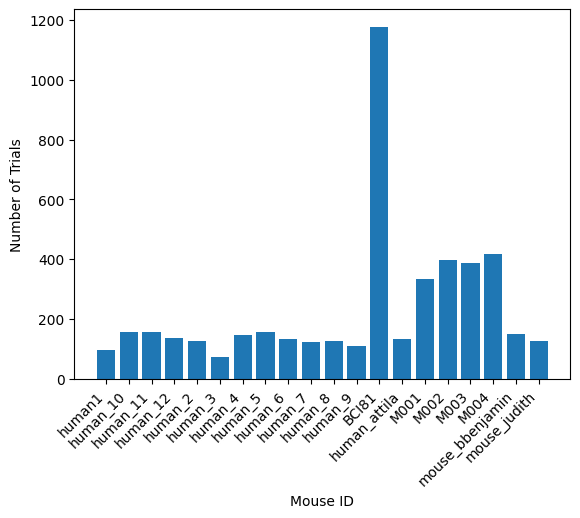

In [3]:
# find the mouse IDs that have been used in the experiment and count the number of trials for each mouse, then plot a bar graph
mouse_IDs = lab.Subject.fetch('subject_id')
trial_nums = []
for m in mouse_IDs:
    trial_nums.append(len((experiment.SessionTrial()&{'subject_id':m})))
trial_nums = np.array(trial_nums)
needed_mice = trial_nums>0

fig = plt. figure()
plt.bar(mouse_IDs[needed_mice], trial_nums[needed_mice])
plt.xticks(rotation=45, ha="right")
plt.xlabel('Mouse ID')
plt.ylabel('Number of Trials')


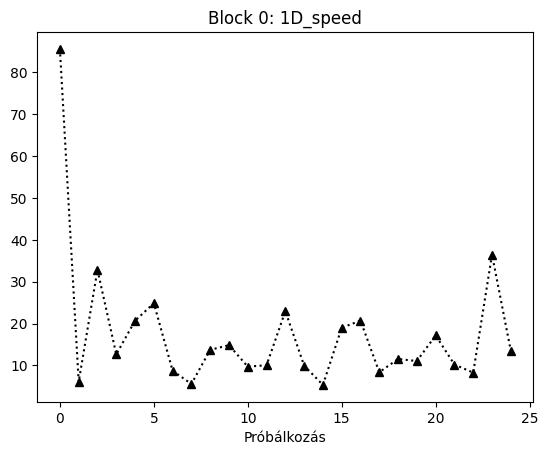

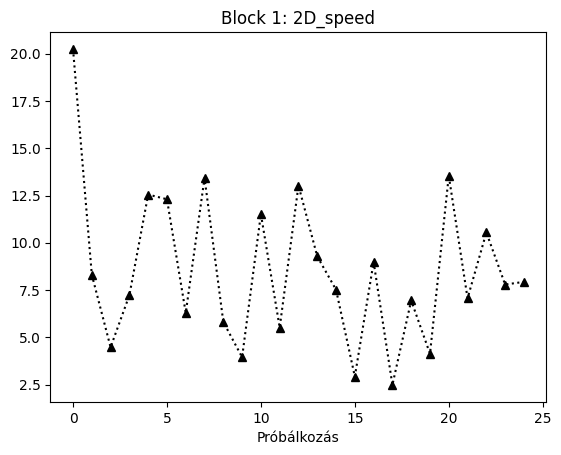

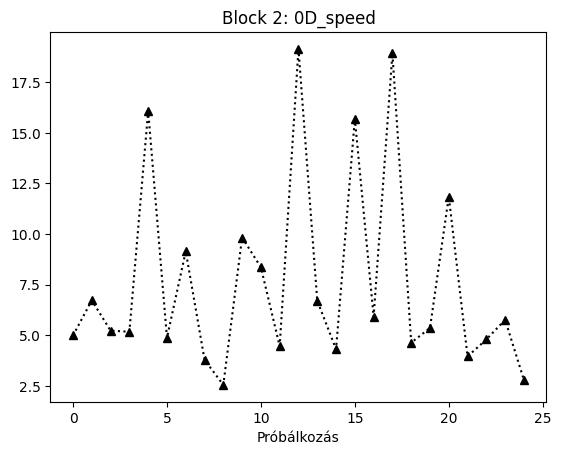

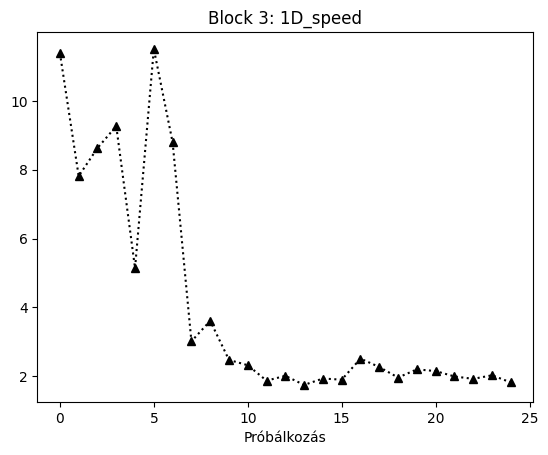

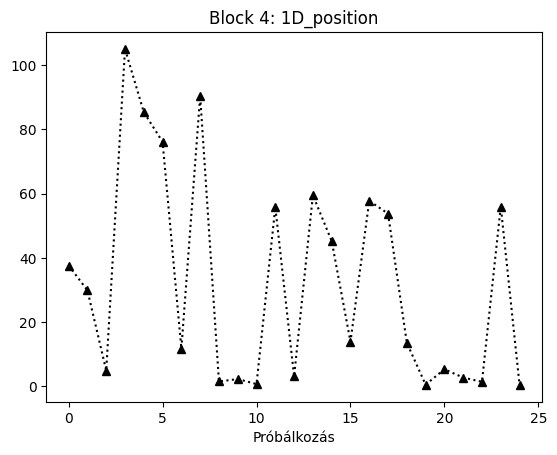

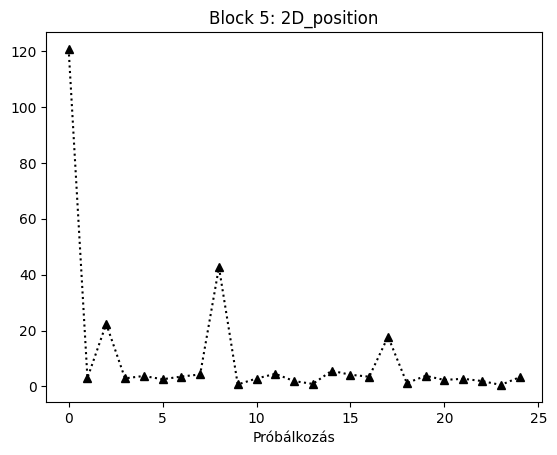

In [ ]:
subject_id = 'human_5'
session = 0
block_dict_list = (experiment.Block()&{'subject_id':subject_id, 'session':session}).fetch(as_dict=True)
for block_dict in block_dict_list:
    block_num = block_dict['block']
    feedback_type = block_dict['feedback_type']
    rewarded_trial, time_to_reward = (experiment.TrialEvent()*experiment.BehaviorTrial()*experiment.Block()&{'subject_id':subject_id,'trial_event_type':'threshold crossing','block':block_num}).fetch('trial','trial_event_time') 
    fig = plt.figure()
    ax1 = fig.add_subplot(1,1,1)
    ax1.plot(time_to_reward,'^k:')#,color = 'blue')
    ax1.set_title(f'Block {block_num}: {feedback_type}')
    ax1.set_xlabel('Próbálkozás')
    #y tengelyt is feliratozni


# FELADAT
# vedd ki az első megoldási időt minden blokkból, és hasonlítsd össze a különböző feedback típusok között. 
# vedd ki az utolsó előtti megoldási időt minden blokkból, és hasonlítsd össze a különböző feedback típusok között.  (vagy átlagold az utolsó 5 megoldási időt.)
# találd meg az első olyan próbálkozást, ami fele olyan sokáig tart, mint az első megoldási idő, és hasonlítsd össze a különböző feedback típusok között.
# iterálj végig a különböző emberek között, és írasd ki az összes fentit

In [29]:
time_to_reward

array([Decimal('10.60000'), Decimal('5.22000'), Decimal('3.92800'),
       Decimal('3.24198'), Decimal('2.22400'), Decimal('3.63798'),
       Decimal('2.45600'), Decimal('3.55200'), Decimal('4.56598'),
       Decimal('2.55002'), Decimal('2.26800'), Decimal('1.95802'),
       Decimal('2.45600'), Decimal('2.45398'), Decimal('2.11802'),
       Decimal('2.49802'), Decimal('2.01798'), Decimal('2.10400'),
       Decimal('5.15200'), Decimal('3.42202'), Decimal('3.12198'),
       Decimal('2.96602'), Decimal('2.27600'), Decimal('4.06800'),
       Decimal('1.49798')], dtype=object)

In [28]:
experiment.TrialEvent()*experiment.Block()*experiment.BehaviorTrial()&{'subject_id':subject_id,'block':1}

subject_id,session session number - A session is defined as a recording/behavior session with a maximum of 60 minutes break between recordings,trial trial number,trial_event_type,trial_event_id,"block block number within session, ordered chronologically","trial_event_time (s) from trial start, not session start",trial_event_duration (s),task_setting_id,feedback_type,block_start_time (s) relative to session beginning,block_end_time (s) relative to session beginning,outcome
human_7,0,26,go,0,1,0.72198,0.10000,1,2D_speed,213.48179,308.27978,miss
human_7,0,26,threshold crossing,1,1,10.60000,0.05000,1,2D_speed,213.48179,308.27978,miss
human_7,0,27,go,0,1,0.61200,0.10000,1,2D_speed,213.48179,308.27978,miss
human_7,0,27,threshold crossing,1,1,5.22000,0.05000,1,2D_speed,213.48179,308.27978,miss
human_7,0,28,go,0,1,0.61600,0.10000,1,2D_speed,213.48179,308.27978,miss
human_7,0,28,threshold crossing,1,1,3.92800,0.05000,1,2D_speed,213.48179,308.27978,miss
human_7,0,29,go,0,1,0.61200,0.10000,1,2D_speed,213.48179,308.27978,miss


In [26]:
block = 1
rewarded_trial, time_to_reward = (experiment.TrialEvent()*experiment.BehaviorTrial()*experiment.Block()&{'subject_id':subject_id,'session':session,'trial_event_type':'threshold crossing','block':block}).fetch('trial','trial_event_time')    #break

